In [118]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys

import importlib

# # import  settings
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver2
importlib.reload(exp_pybamm_ver2)

<module 'exp_pybamm_ver2' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/exp_pybamm_ver2.py'>

In [119]:
def V_terminal(U, eta_r):
    return U - eta_r

def OCV(opc_n,opc_p):
    return opc_p - opc_n

def exchange_current_dens(c,K = 0.25):
    c_reduced = c[-1,...]/ np.max(c)
    
    return K * np.sqrt(c_reduced * (1-c_reduced))


def eta_r(i_app,cp,cn, T = 298,Ln = 44,Lp = 44, K = 0.05):
    R = sc.R
    F = sc.physical_constants['Faraday constant'][0]
    jp0 = exchange_current_dens(cp,K)
    jn0 = exchange_current_dens(cn,K)
    jn = i_app / Ln
    jp = -i_app / Lp
    return 2 * R * T / F * (np.arcsinh(jn/jn0)-np.arcsinh(jp/(jp0)))



In [120]:
t,_, I, ocp_p = exp_pybamm_ver2.get_values('X-averaged positive electrode open-circuit potential [V]',model = 'SPM')
t,_, I, ocp_n = exp_pybamm_ver2.get_values('X-averaged negative electrode open-circuit potential [V]',model = 'SPM')
t,_, I, cn = exp_pybamm_ver2.get_values('X-averaged negative particle concentration [mol.m-3]',model = 'SPM')
t,_, I, cp = exp_pybamm_ver2.get_values('X-averaged positive particle concentration [mol.m-3]',model = 'SPM')
t,_, I, V_true = exp_pybamm_ver2.get_values('Terminal voltage [V]',model = 'SPM')


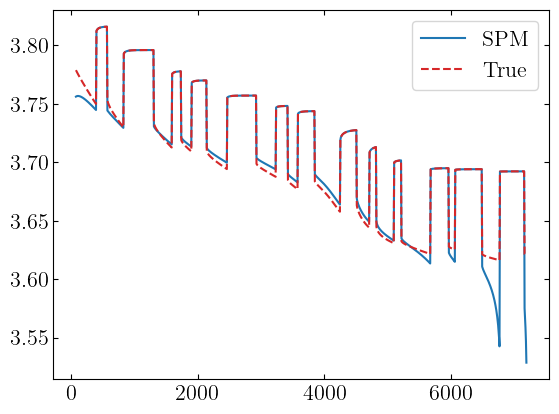

In [121]:
    

V = V_terminal(OCV(ocp_n,ocp_p), eta_r(I,cp,cn))
plt.plot(t[10:], V[10:],color = 'tab:blue', label = 'SPM')
plt.plot(t[10:], V_true[10:],color = 'tab:red',ls = '--', label = 'True')
plt.legend()    